In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

def plot_map(T, i, save_path=None):
    """
    Визуализация {i}-ой карты с начальной и конечной точками, а также результатом Дейкстры с прозрачными областями вне карты.

    Параметры:
        T (np.ndarray): Тензор данных размером (N, 64, 64, 4).
        i (int): Индекс карты для отображения.
        save_path (str): Путь для сохранения изображения (если указан).
    """
    B = T[..., 1]
    C = T[..., 2]
    D = T[..., 3]

    # Копируем массив расстояний и заменяем нули на NaN для прозрачных областей
    distances = np.copy(C[i])
    distances[distances == 0] = np.nan

    # Создаем цветовую карту с прозрачным фоном
    cmap = plt.cm.viridis
    cmap.set_bad(color=(0, 0, 0, 0))  # Прозрачный цвет для NaN

    plt.figure(figsize=(6, 6), dpi=100)
    plt.title(f"Map {i + 1}: Landscape with Points")

    # Визуализация карты с прозрачным фоном для областей вне карты
    img = plt.imshow(distances, cmap=cmap, vmin=0, vmax=np.nanmax(distances))

    # Наносим начальную и конечную точки
    start_point = np.argwhere(D[i] == 1)
    end_point = np.argwhere(B[i] == 1)

    if len(start_point) > 0:
        plt.scatter(start_point[0, 1], start_point[0, 0], color='blue', label='Start', s=100)
    if len(end_point) > 0:
        plt.scatter(end_point[0, 1], end_point[0, 0], color='red', label='End', s=100)

    plt.legend()
    plt.colorbar(img, label='Distance to End Point')

    # Сохраняем изображение, если указан путь
    if save_path:
        plt.savefig(save_path, transparent=True, bbox_inches='tight')

    plt.show()

In [3]:
def plot_multiple_maps(T, num_maps=5, save_dir="maps"):
    """
    Отображение нескольких карт с сохранением изображений.

    Параметры:
        T (np.ndarray): Тензор данных размером (N, 64, 64, 4).
        num_maps (int): Количество карт для отображения.
        save_dir (str): Директория для сохранения изображений.
    """
    import os

    # Создаем директорию для сохранения изображений, если её нет
    os.makedirs(save_dir, exist_ok=True)

    for i in range(min(num_maps, T.shape[0])):
        save_path = os.path.join(save_dir, f"map_{i + 1}.pdf")
        plot_map(T, i, save_path=save_path)

(64, 64)
(1, 64, 64)


Mark start: 100%|██████████| 1/1 [00:00<00:00, 1122.37it/s]


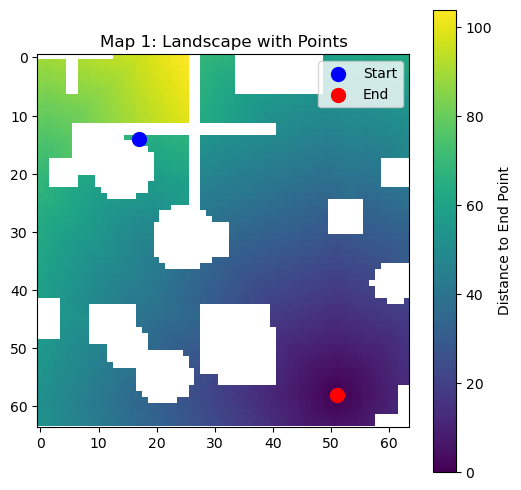

In [ ]:
from map_generators.figures import generate_figures
from ABCD.ABCD import generate_BCD
a = generate_figures(64)
b = a.shape
print(b)
a = np.expand_dims(a, axis=0)
print(a.shape)
c = generate_BCD(a)
plot_map(c, 0)

Mark start: 100%|██████████| 1/1 [00:00<00:00, 2178.86it/s]


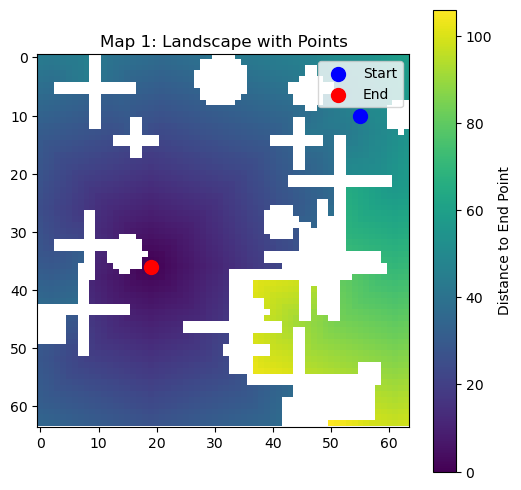

Mark start: 100%|██████████| 1/1 [00:00<00:00, 2437.13it/s]


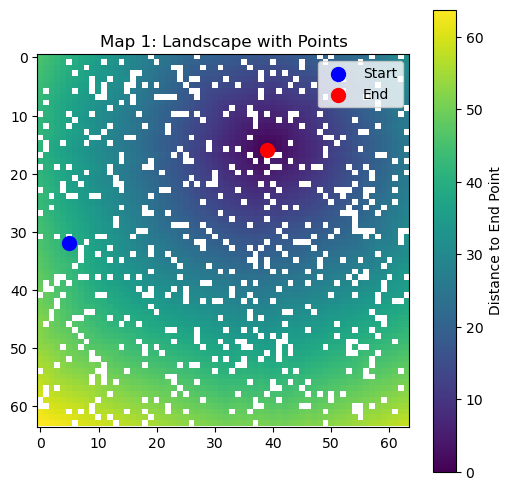

In [123]:
from map_generators.QR_maps import generate_QRs
a = np.expand_dims(generate_train01(64), axis=0)
dumbQR = np.random.choice([0, 1], size=(64, 64), p=[0.15, 0.85])
dumbQR = np.expand_dims(dumbQR, axis=0)

plot_map(generate_BCD(a), 0)
plot_map(generate_BCD(dumbQR), 0)

Mark start: 100%|██████████| 1/1 [00:00<00:00, 1551.15it/s]


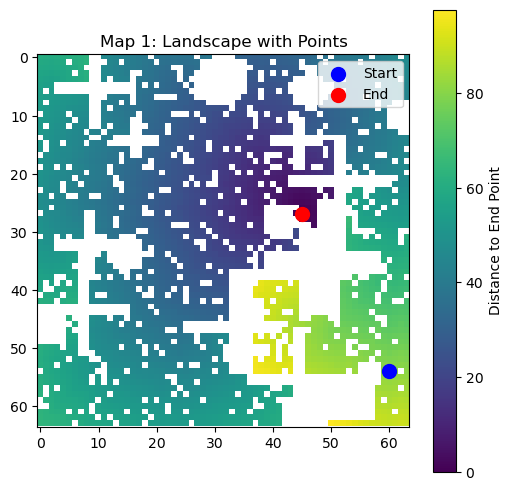

In [124]:
res = a & dumbQR
plot_map(generate_BCD(res), 0)